# EDA for ML Project

## Step 1: Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Step 2: Preprocessing

In [2]:
def preprocess_data(train_df, test_df):
    # 1. Normalize data using log transformation to SalePrice
    y_train = np.log1p(train_df['SalePrice'])
    train_df = train_df.drop('SalePrice', axis=1)

    # Model needs to see same set of column in both training and testing
    all_data = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

    # 2. Fill in Categorical Missing data with one -> prep one hot encoding
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'MasVnrType']
    for col in none_cols:
        all_data[col] = all_data[col].fillna('None')

    # 3. Handle Numerical/True Missing
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
    all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(all_data['YearBuilt'])
    all_data['MasVnrArea'] = all_data['MasVnrArea'].fillna(0)
    all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

    # Fill remaining numerical missing before calculation
    for col in all_data.select_dtypes(include=[np.number]).columns:
        all_data[col] = all_data[col].fillna(all_data[col].median())

    # 4. Feature Extraction: Total Square Footage
    all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

    # Fill remaining missing with mode for objects
    for col in all_data.select_dtypes(include=['object']).columns:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

    # 5. One-Hot Encoding
    all_data = pd.get_dummies(all_data)

    # Split back
    X_train = all_data[:len(train_df)]
    X_test = all_data[len(train_df):]

    return X_train, X_test, y_train

In [3]:
# Execute loading and preprocessing
trainingDF = pd.read_csv('./data/train.csv')
testDF = pd.read_csv('./data/test.csv')
X_train, X_test, y_train = preprocess_data(trainingDF, testDF)

print(f'Processed X_train shape: {X_train.shape}')
print(f'TotalSF included in features: {"TotalSF" in X_train.columns}')

Processed X_train shape: (1460, 304)
TotalSF included in features: True


## Part 3: Feature Extraction (with the options of PCA (default) or LDA)

In [4]:
def extract_features(
    X_train,
    X_test,
    y_train=None,
    method='pca',
    n_components=0.95,
    scale=True,
    n_lda_bins=5,
    random_state=42,
):
    """Apply PCA or LDA feature extraction to train/test sets.

    Args:
        X_train: Training features (DataFrame or ndarray).
        X_test: Test features (DataFrame or ndarray).
        y_train: Required for LDA. If continuous, it is binned with qcut.
        method: 'pca', 'lda', or 'none'.
        n_components: PCA components/int or explained variance float; for LDA use int/float/None.
        scale: Whether to standardize before extraction.
        n_lda_bins: Number of quantile bins when y_train is continuous for LDA.
        random_state: Random state for reproducibility where applicable.

    Returns:
        X_train_new, X_test_new, fitted_extractor
    """
    method = method.lower()
    X_train_vals = X_train.values if hasattr(X_train, 'values') else X_train
    X_test_vals = X_test.values if hasattr(X_test, 'values') else X_test

    scaler = None
    if scale:
        scaler = StandardScaler()
        X_train_vals = scaler.fit_transform(X_train_vals)
        X_test_vals = scaler.transform(X_test_vals)

    if method == 'none':
        return (
            pd.DataFrame(X_train_vals, index=getattr(X_train, 'index', None)),
            pd.DataFrame(X_test_vals, index=getattr(X_test, 'index', None)),
            None,
        )
    # Section for Principal Component Analysis
    if method == 'pca':
        extractor = PCA(n_components=n_components, random_state=random_state)
        X_train_new = extractor.fit_transform(X_train_vals)
        X_test_new = extractor.transform(X_test_vals)
        cols = [f'PC{i+1}' for i in range(X_train_new.shape[1])]
    # Section for Linear Discriminant Analysis
    elif method == 'lda':
        if y_train is None:
            raise ValueError("y_train is required for LDA.")

        # For regression targets, bin into ordinal classes for supervised projection.
        y_series = pd.Series(y_train)
        if y_series.nunique() > n_lda_bins:
            y_labels = pd.qcut(y_series, q=n_lda_bins, labels=False, duplicates='drop')
        else:
            y_labels = y_series

        n_classes = pd.Series(y_labels).nunique()
        max_lda_components = min(X_train_vals.shape[1], n_classes - 1)
        if max_lda_components < 1:
            raise ValueError("LDA needs at least 2 classes after binning.")

        if n_components is None:
            lda_components = max_lda_components
        elif isinstance(n_components, float):
            if 0 < n_components < 1:
                # Interpret floats in (0, 1) as a fraction of available LDA dimensions.
                lda_components = int(np.ceil(max_lda_components * n_components))
            else:
                lda_components = int(round(n_components))
        else:
            lda_components = int(n_components)

        lda_components = max(1, min(lda_components, max_lda_components))

        extractor = LinearDiscriminantAnalysis(n_components=lda_components)
        X_train_new = extractor.fit_transform(X_train_vals, y_labels)
        X_test_new = extractor.transform(X_test_vals)
        cols = [f'LD{i+1}' for i in range(X_train_new.shape[1])]

    else:
        raise ValueError("method must be one of: 'pca', 'lda', 'none'.")

    X_train_new = pd.DataFrame(X_train_new, index=getattr(X_train, 'index', None), columns=cols)
    X_test_new = pd.DataFrame(X_test_new, index=getattr(X_test, 'index', None), columns=cols)
    return X_train_new, X_test_new, extractor

In [5]:
X_train_none, X_test_none, none_model = extract_features(
    X_train, X_test, y_train=y_train, method='None', n_components=0.95, scale=True
)

print(f'None train shape: {X_train_none.shape}')
print(f'None test shape: {X_test_none.shape}')

None train shape: (1460, 304)
None test shape: (1459, 304)


In [6]:
# PCA model
X_train_pca, X_test_pca, pca_model = extract_features(
    X_train, X_test, y_train=y_train, method='pca', n_components=0.95, scale=True
)

print(f'PCA train shape: {X_train_pca.shape}')
print(f'PCA test shape: {X_test_pca.shape}')
print(f'Explained variance: {pca_model.explained_variance_ratio_.sum():.4f}')

PCA train shape: (1460, 182)
PCA test shape: (1459, 182)
Explained variance: 0.9507


In [7]:
# LDA model
X_train_lda, X_test_lda, lda_model = extract_features(
    X_train, X_test, y_train=y_train, method='lda', n_components=0.95, scale=True
)
print(f'LDA train shape: {X_train_lda.shape}')
print(f'LDA test shape: {X_test_lda.shape}')
print(f'Explained variance: {lda_model.explained_variance_ratio_.sum():.4f}')

LDA train shape: (1460, 4)
LDA test shape: (1459, 4)
Explained variance: 1.0000


In [8]:
X_trNone, X_valNone, y_trNone, y_valNone = train_test_split(
    X_train_none, y_train, test_size=0.2, random_state=42
)

rf_modelNone = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    oob_score=True,
    bootstrap=True,
    )

rf_modelNone.fit(X_trNone, y_trNone)

val_pred_logNone = rf_modelNone.predict(X_valNone)
rmse_logNone = np.sqrt(mean_squared_error(y_valNone, val_pred_logNone))

print(f'Validation RMSE (log SalePrice): {rmse_logNone:.5f}')
print(f'OOB Score (R^2 on training bootstrap): {rf_modelNone.oob_score_:.5f}')

rf_modelNone.fit(X_train_none, y_train)
test_pred_logNone = rf_modelNone.predict(X_test_none)
test_predNone = np.expm1(test_pred_logNone)

submissionNone = pd.DataFrame({
    'Id': testDF['Id'],
    'SalePrice': test_predNone
})

Validation RMSE (log SalePrice): 0.15499
OOB Score (R^2 on training bootstrap): 0.84834


In [9]:
# Use extracted features from PCA (you can swap to X_train / X_test if preferred)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1, # Uses all available CPU cores
    oob_score=True,
    bootstrap=True,
    )

rf_model.fit(X_tr, y_tr)

val_pred_log = rf_model.predict(X_val)
rmse_log = np.sqrt(mean_squared_error(y_val, val_pred_log))

print(f'Validation RMSE (log SalePrice): {rmse_log:.5f}')
print(f'OOB score (R^2 on training bootstrap): {rf_model.oob_score_:.5f}')

# Train on full training set and predict test set
rf_model.fit(X_train_pca, y_train)
test_pred_log = rf_model.predict(X_test_pca)
test_pred = np.expm1(test_pred_log)

submissionPCA = pd.DataFrame({
    'Id': testDF['Id'],
    'SalePrice': test_pred
})

Validation RMSE (log SalePrice): 0.16771
OOB score (R^2 on training bootstrap): 0.83506


In [10]:
X_trLDA, X_valLDA, y_trLDA, y_valLDA = train_test_split(
    X_train_lda, y_train, test_size=0.2, random_state=42
)

rf_modelLDA = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    oob_score=True,
    bootstrap=True,
    )

rf_modelLDA.fit(X_trLDA, y_trLDA)

val_pred_logLDA = rf_modelLDA.predict(X_valLDA)
rmse_logLDA = np.sqrt(mean_squared_error(y_valLDA, val_pred_logLDA))

print(f'Validation RMSE (log SalePrice): {rmse_logLDA:.5f}')
print(f'OOB score (R^2 on training bootstrap): {rf_modelLDA.oob_score_:.5f}')

# Train on full training set and predict test set
rf_modelLDA.fit(X_train_lda, y_train)
test_pred_logLDA = rf_modelLDA.predict(X_test_lda)
test_predLDA = np.expm1(test_pred_logLDA)

submissionLDA = pd.DataFrame({
    'Id': testDF['Id'],
    'SalePrice': test_predLDA
})

Validation RMSE (log SalePrice): 0.13356
OOB score (R^2 on training bootstrap): 0.90218


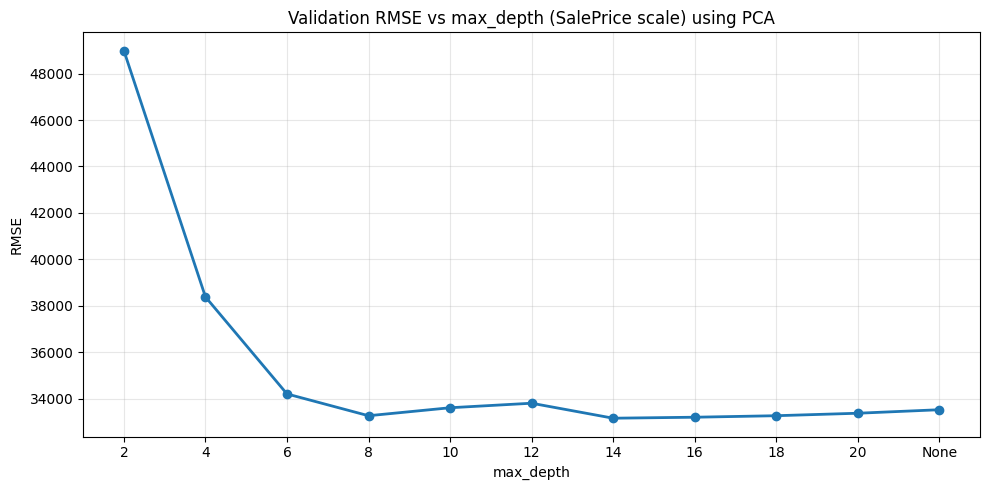

max_depth=   2 -> RMSE = $48,982.46
max_depth=   4 -> RMSE = $38,388.63
max_depth=   6 -> RMSE = $34,213.00
max_depth=   8 -> RMSE = $33,275.10
max_depth=  10 -> RMSE = $33,618.44
max_depth=  12 -> RMSE = $33,813.21
max_depth=  14 -> RMSE = $33,168.42
max_depth=  16 -> RMSE = $33,210.65
max_depth=  18 -> RMSE = $33,275.81
max_depth=  20 -> RMSE = $33,382.20
max_depth=None -> RMSE = $33,533.09


In [11]:
# Plot RMSE on original SalePrice scale vs max_depth (not log scale)
depth_values = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, None]
rmse_values = []
y_val_actual = np.expm1(y_val)

for depth in depth_values:
    depth_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
        bootstrap=True,
    )
    depth_model.fit(X_tr, y_tr)
    val_pred_log_depth = depth_model.predict(X_val)
    val_pred_depth = np.expm1(val_pred_log_depth)
    rmse_depth = np.sqrt(mean_squared_error(y_val_actual, val_pred_depth))
    rmse_values.append(rmse_depth)

x_labels = [str(d) if d is not None else 'None' for d in depth_values]

plt.figure(figsize=(10, 5))
plt.plot(x_labels, rmse_values, marker='o', linewidth=2)
plt.title('Validation RMSE vs max_depth (SalePrice scale) using PCA')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for d, r in zip(x_labels, rmse_values):
    print(f'max_depth={d:>4} -> RMSE = ${r:,.2f}')

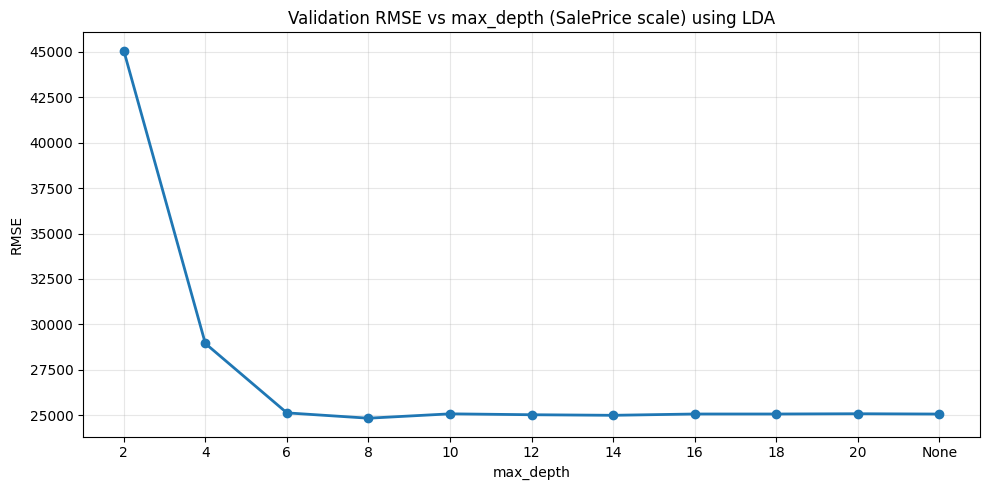

max_depth=   2 -> RMSE = $45,058.73
max_depth=   4 -> RMSE = $28,949.11
max_depth=   6 -> RMSE = $25,131.36
max_depth=   8 -> RMSE = $24,837.66
max_depth=  10 -> RMSE = $25,078.33
max_depth=  12 -> RMSE = $25,028.73
max_depth=  14 -> RMSE = $24,997.23
max_depth=  16 -> RMSE = $25,069.11
max_depth=  18 -> RMSE = $25,068.90
max_depth=  20 -> RMSE = $25,083.45
max_depth=None -> RMSE = $25,066.59


In [12]:
# Plot RMSE on original SalePrice scale vs max_depth (not log scale)
depth_values = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, None]
rmse_values = []
y_val_actual = np.expm1(y_valLDA)

for depth in depth_values:
    depth_modelLDA = RandomForestRegressor(
        n_estimators=300,
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
        bootstrap=True,
    )
    depth_modelLDA.fit(X_trLDA, y_trLDA)
    val_pred_log_depth = depth_modelLDA.predict(X_valLDA)
    val_pred_depth = np.expm1(val_pred_log_depth)
    rmse_depth = np.sqrt(mean_squared_error(y_val_actual, val_pred_depth))
    rmse_values.append(rmse_depth)

x_labels = [str(d) if d is not None else 'None' for d in depth_values]

plt.figure(figsize=(10, 5))
plt.plot(x_labels, rmse_values, marker='o', linewidth=2)
plt.title('Validation RMSE vs max_depth (SalePrice scale) using LDA')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("MaxDepthLDA.png")
plt.show()

for d, r in zip(x_labels, rmse_values):
    print(f'max_depth={d:>4} -> RMSE = ${r:,.2f}')

In [13]:
# Predicted price for ID 1461 + metrics (R^2 and RMSE on original scale)

target_id = 1461

id_index = testDF[testDF['Id'] == target_id].index[0]
test_position = testDF.index.get_loc(id_index)

pca_pred_log = rf_model.predict(X_test_pca.iloc[[test_position]])[0]
pca_pred_price = np.expm1(pca_pred_log)

lda_pred_log = rf_modelLDA.predict(X_test_lda.iloc[[test_position]])[0]
lda_pred_price = np.expm1(lda_pred_log)

print(f"Predicted SalePrice for ID {target_id}:")
print(f"  PCA model: ${pca_pred_price:,.2f}")
print(f"  LDA model: ${lda_pred_price:,.2f}")



Predicted SalePrice for ID 1461:
  PCA model: $126,333.61
  LDA model: $132,090.92


In [14]:
# Metrics on original SalePrice scale
none_val_pred_price = np.expm1(val_pred_logNone)

pca_val_pred_price = np.expm1(val_pred_log)

lda_val_pred_price = np.expm1(val_pred_logLDA)

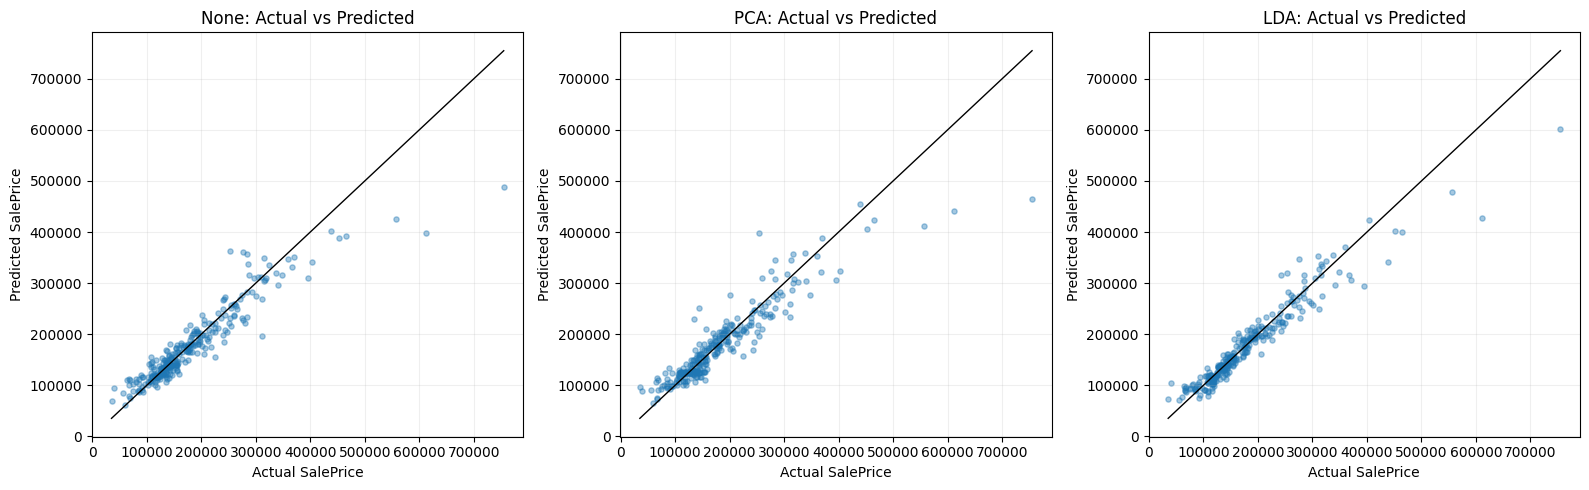

In [15]:
# Actual vs predicted SalePrice plots (validation)
plots = [
    ("None", np.expm1(y_valNone), none_val_pred_price),
    ("PCA", np.expm1(y_val), pca_val_pred_price),
    ("LDA", np.expm1(y_valLDA), lda_val_pred_price),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_true, y_pred) in zip(axes, plots):
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.scatter(y_true, y_pred, s=14, alpha=0.4)
    ax.plot([min_val, max_val], [min_val, max_val], color="black", linewidth=1)
    ax.set_title(f"{name}: Actual vs Predicted")
    ax.set_xlabel("Actual SalePrice")
    ax.set_ylabel("Predicted SalePrice")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("ActualvsPredictedGraph.png")
plt.show()


In [16]:
# None results
none_r2_val = r2_score(np.expm1(y_valNone), none_val_pred_price)
none_rmse_val = np.sqrt(mean_squared_error(np.expm1(y_valNone), none_val_pred_price))

print("\nNone metrics (original scale):")
print(f"  R^2 validation: {none_r2_val:.4f}")
print(f"  RMSE validation: ${none_rmse_val:,.2f}")


None metrics (original scale):
  R^2 validation: 0.8641
  RMSE validation: $32,283.52


In [17]:
# PCA results

pca_r2_val = r2_score(np.expm1(y_val), pca_val_pred_price)
pca_rmse_val = np.sqrt(mean_squared_error(np.expm1(y_val), pca_val_pred_price))

print("\nPCA metrics (original scale):")
print(f"  R^2 validation: {pca_r2_val:.4f}")
print(f"  RMSE validation: ${pca_rmse_val:,.2f}")


PCA metrics (original scale):
  R^2 validation: 0.8490
  RMSE validation: $34,033.13


In [18]:
# LDA results

lda_r2_val = r2_score(np.expm1(y_valLDA), lda_val_pred_price)
lda_rmse_val = np.sqrt(mean_squared_error(np.expm1(y_valLDA), lda_val_pred_price))

print("\nLDA metrics (original scale):")
print(f"  R^2 validation: {lda_r2_val:.4f}")
print(f"  RMSE validation: ${lda_rmse_val:,.2f}")


LDA metrics (original scale):
  R^2 validation: 0.9162
  RMSE validation: $25,359.91


In [19]:
# Making PCA csv for Kaggle

submissionPCA.to_csv('submissionPCA.csv', index=False)
print(f"PCA submission saved: {len(submissionPCA)} rows")
print(submissionPCA.head())

print()
# Making LDA csv for Kaggle

submissionLDA.to_csv('submissionLDA.csv', index=False)
print(f"LDA submission saved: {len(submissionLDA)} rows")
print(submissionLDA.head())

PCA submission saved: 1459 rows
     Id      SalePrice
0  1461  126333.614531
1  1462  154171.215833
2  1463  178297.486988
3  1464  197497.509944
4  1465  171671.304174

LDA submission saved: 1459 rows
     Id      SalePrice
0  1461  132090.923613
1  1462  150587.174605
2  1463  175295.847843
3  1464  197080.551352
4  1465  194853.400481
